Importações:

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
estatisticas = "campeonato-brasileiro-estatisticas-full.csv"
full = "campeonato-brasileiro-full.csv"
# Load the latest version
df_estats = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "adaoduque/campeonato-brasileiro-de-futebol",
  estatisticas,

)

df_full = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "adaoduque/campeonato-brasileiro-de-futebol",
  full,
)

display(df_estats.head())
display(df_full.head())

<font size='5'>1 Descrição inicial</font>

<br>De onde vieram os dados?
<br>O que cada coluna significa?
<br>Qual o recorte temporal?
<br>3 a 5 perguntas** que vocês querem responder, definidas **antes** da análise
<br>
<br>*No mínimo 1.000 linhas e 8 colunas
<br>*Pelo menos 3 numéricas e 2 categóricas.

In [ ]:
print(f"Shape do df_estats: {df_estats.shape}")
print(f"Shape do df_full: {df_full.shape}")

In [ ]:
#df_estats.info()
df_full.info()

Aqui abaixo estou realizando o merge e separando dataset com dados a partir de 2018

In [ ]:
df_merge = df_estats.merge(
    df_full, 
    left_on='partida_id',   # Coluna chave no primeiro dataset
    right_on='ID',           # Coluna chave no segundo dataset
    how='inner'              # Tipo de junção (veja as opções abaixo)
)

# 3. (Opcional) Remover uma das colunas repetidas se preferir
# df_resultado = df_resultado.drop(columns=['id'])
#Ainda não está funcionando
#também incluir filtro a partir de 2018
print(df_merge)

In [ ]:
#filtrar dados de 2018 pra frente
import pandas as pd
# Converte a coluna 'data' para datetime indicando o formato dia/mês/ano
df_merge['data'] = pd.to_datetime(df_merge['data'], format='%d/%m/%Y')

# Filtra os anos de 2018 e 2023 - até 2017 e a partir de 2024 muitos dados estão ausentes e prejudicam a análise temporal.
df_filtrado = df_merge[(df_merge['data'].dt.year >= 2018) & (df_merge['data'].dt.year <= 2023)]

#renomeando coluna com nome autonomeado para no merge
df_filtrado = df_filtrado.rename(columns={'rodata_x': 'rodada'})



In [ ]:
df_filtrado.describe()

In [ ]:
#pip install openpyxl
#salvando em excel para visualizar todos os dados
df_filtrado.to_excel('arquivo_2026-09-15.xlsx', index=False)

In [ ]:
#Eliminando colunas repetidas ou que não tem relevância na análise e criando o dataframe que será usado nos tratamentos de dados daqui pra frente
df_diagnostico = df_filtrado.drop(columns=['ID','rodata_y','tecnico_mandante','tecnico_visitante','arena','arrecadacao'])

<font size='5'>2 Diagnóstico de qualidade</font>
<br>
<br>2.1 Dimensões, tipos, uso de memória
<br>2.2 Faltantes por coluna (quantidade e percentual)
<br>Duplicados, categorias inconsistentes, valores inválidos
<br>Identificação de outliers com método justificado (IQR ou z-score), avaliados no **grupo de comparação correto**

In [ ]:
# 2.1 Dimensões, tipos, uso de memória
print("shape:", df_diagnostico.shape)
df_diagnostico.info(memory_usage='deep')

In [ ]:
# 2 - Estatísticas descritivas das colunas numéricas e texto/objeto

display(df_diagnostico.describe().round(2))
display(df_diagnostico.describe(include='object'))

In [ ]:
#identificar o que é um NA nessa tabela
#3 Quantidade e percentual de valores faltantes

faltantes = pd.DataFrame({
    'faltantes': df_diagnostico.isna().sum(),
    'pct': (df_diagnostico.isna().mean() * 100).round(2)
})
faltantes = faltantes[faltantes['faltantes'] > 0].sort_values('faltantes', ascending=False)
faltantes



In [ ]:
#4 Linhas com pelo menos um NA x Linhas completas

print("linhas com algum NaN:", df_diagnostico.isna().any(axis=1).sum())
print("linhas completas    :", df_diagnostico.notna().all(axis=1).sum())

In [ ]:
#5 Para colunas categóricas: Quantos valores distintos e frequência de cada valor

for col in ['clube']:
    print(f"--- {col} | {df_diagnostico[col].nunique()} valores distintos ---")
    print(df_diagnostico[col].value_counts(dropna=False), '\n')


In [ ]:
#6 Identificar problemas nos valores categóricos

print(sorted(df_diagnostico['clube'].unique()))
# 'São Paulo', ' são paulo ' e 'SAO PAULO' são a MESMA loja escrita de formas diferentes:
# espaços nas bordas, caixa diferente e ausência de acento.
#print("linhas afetadas:", df['loja'].isin([' são paulo ', 'SAO PAULO']).sum())

In [ ]:
#7 Padronizar valores categóricos
''' - esse fica mais pra baixo e precisa descobrir onde fazer
df['loja'] = df['loja'].str.strip().str.title()
df['loja'] = df['loja'].replace({'Sao Paulo': 'São Paulo'})
print(df['loja'].value_counts())
print("lojas distintas:", df['loja'].nunique())'''

In [ ]:
#8 Nas colunas ID identificar se existem linhas duplicadas
print("ids duplicados:", df_diagnostico['partida_id'].duplicated().sum())
print("ids únicos:", df_diagnostico['partida_id'].nunique(), "| linhas:", len(df))

In [ ]:
#9 Caso existam colunas total NA, excluir
'''
vazias = df.columns[df.isna().all()]
print("removendo:", list(vazias))
df = df.drop(columns=vazias)
print(df.shape)'''

In [ ]:
#10 Comparar soluções para preencher valores faltantes

col = df['preco_unitario']
op1 = df.dropna(subset=['preco_unitario'])
op2 = col.fillna(col.mean())
op3 = col.fillna(df.groupby('produto')['preco_unitario'].transform('median'))

print(f"original : {len(df)} linhas | média {col.mean():.2f}")
print(f"opção 1  : {len(op1)} linhas | média {op1['preco_unitario'].mean():.2f}")
print(f"opção 2  : {len(df)} linhas | média {op2.mean():.2f}")
print(f"opção 3  : {len(df)} linhas | média {op3.mean():.2f}")



In [ ]:
#11 Sugestao preencher com mediana do produto

df['preco_unitario'] = df['preco_unitario'].fillna(
    df.groupby('produto')['preco_unitario'].transform('median'))
print("faltantes restantes:", df['preco_unitario'].isna().sum())
# O preço varia MUITO entre produtos (Mouse ~90, Notebook ~3500). A média geral
# atribuiria a um mouse um preço absurdo; a mediana por produto respeita a estrutura
# dos dados e é robusta a outliers.


In [ ]:

#12 Sugestão preencher com a mediana geral se for um valor mais geral

df_limpeza=df_diagnostico

### Exercício 4.5
#Para `quantidade`, preencha os faltantes com a **mediana geral** e converta a coluna de volta para inteiro.

In [ ]:

#13 Justificar preenchimento em caso de coluna que permanecerá NA


In [ ]:
#Valores inválidos ou atípicos

#14 Nesse caso valores precisam estar entre 0 e 1

invalidos = df['desconto'] > 1
print("registros inválidos:", invalidos.sum())
display(df.loc[invalidos, ['id_venda', 'produto', 'desconto']])

df.loc[invalidos, 'desconto'] = np.nan          # é erro de digitação: não sabemos o valor real
df['desconto'] = df['desconto'].fillna(0)       # sem informação, assume-se sem desconto
print("máximo agora:", df['desconto'].max())

In [ ]:
#15 Relatório de limpeza
relatorio = pd.DataFrame([
    ('Categorias inconsistentes em `loja`', 'Padronizadas com strip + title + replace', 55),
    ('Linhas totalmente duplicadas', 'Removidas mantendo a primeira ocorrência', 18),
    ('Coluna `obs` 100% vazia', 'Coluna removida', 1),
    ('Sentinela 999 em `quantidade`', 'Convertido para NaN e imputado pela mediana', 12),
    ('Faltantes em `preco_unitario`', 'Imputados pela mediana do produto', 25),
    ('`desconto` fora da faixa [0,1]', 'Zerados', 4),
    ('Outliers de preço por produto', 'Substituídos pela mediana do produto', int(df_limpeza['outlier_preco'].sum())),
    ('Faltantes em `avaliacao`', 'Mantidos; criada a coluna `avaliou`', int(df_limpeza['avaliacao'].isna().sum())),
], columns=['Problema encontrado', 'Tratamento aplicado', 'Registros afetados'])
relatorio

In [ ]:
#opcional

#16 Salvar o resultado tratado em um csv

limpa = df_limpeza.drop(columns=['outlier_preco', 'outlier_z'])
limpa.to_csv('vendas_limpas.csv', index=False)

check = pd.read_csv('vendas_limpas.csv', parse_dates=['data'])
print(check.shape)
print(check.isna().sum())

In [ ]:
#17 opcional

#testar esse código como diagnóstico inicial

def diagnostico(df):
    return pd.DataFrame({
        'tipo': df.dtypes.astype(str),
        'faltantes': df.isna().sum(),
        'pct_faltantes': (df.isna().mean() * 100).round(2),
        'distintos': df.nunique(),
        'mais_frequente': [df[c].mode().iloc[0] if df[c].notna().any() else None
                           for c in df.columns],
    })

diagnostico(limpa)

<font size='5'>3 Limpeza e transformação</font>
<br><br>
Cada decisão de tratamento **justificada em texto**: por que imputar em vez de remover? por que a mediana do grupo e não a média geral?
Ao menos: tratamento de faltantes, remoção/consolidação de duplicados, padronização de categorias, criação de pelo menos 3 colunas derivadas
Uso de `map`, `apply`, `np.where`/`np.select`, `cut`/`qcut` onde fizer sentido
<br><br>
Nunca apague nada sem antes medir o impacto e justificar a decisão

In [ ]:
#No final salva o arquivo tratado em .csv para poder realizar as análises sem precisar retornar às etapas anteriores

df_limpeza.to_csv('campeonato_brasileiro_tratado.csv', encoding='utf-8', index=False)

<font size='5'>4 Análise exploratória</font>
<br>
<br>Respostas às perguntas definidas no item 1, com evidência numérica
<br>Uso obrigatório de: `groupby` com agregação múltipla, ao menos um `merge` (pode ser com uma tabela auxiliar que vocês montarem) e ao menos uma `pivot_table`
<br>Ao menos 4 gráficos, cada um acompanhado de uma leitura em texto (o gráfico sozinho não conta)
<br>Uso de NumPy em pelo menos um cálculo relevante (normalização, z-score, operação matricial, simulação)

In [143]:
#1 Abrir arquivo CSV com o relatório tratatado
import pandas as pd

df = pd.read_csv('campeonato_brasileiro_tratado.csv')

df.head()

,partida_id,rodada,clube,chutes,chutes_no_alvo,posse_de_bola,passes,precisao_passes,faltas,cartao_amarelo,cartao_vermelho,impedimentos,escanteios,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,vencedor,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado
0,6126,1,Cruzeiro,12,2,40%,425,81%,20,3,0,0,7,2018-04-14,16:00,Cruzeiro,Gremio,4-2-3-1,4-2-3-1,Gremio,0,1,MG,RS
1,6126,1,Gremio,6,2,60%,649,86%,15,1,1,3,4,2018-04-14,16:00,Cruzeiro,Gremio,4-2-3-1,4-2-3-1,Gremio,0,1,MG,RS
2,6127,1,Vitoria,21,6,66%,545,88%,24,3,0,2,4,2018-04-14,19:02,Vitoria,Flamengo,4-2-3-1,4-1-4-1,-,2,2,BA,RJ
3,6127,1,Flamengo,10,5,34%,286,72%,10,2,1,2,5,2018-04-14,19:02,Vitoria,Flamengo,4-2-3-1,4-1-4-1,-,2,2,BA,RJ
4,6128,1,Santos,22,3,54%,532,90%,7,0,0,1,4,2018-04-14,21:03,Santos,Ceara,4-3-3,4-1-4-1,Santos,2,0,SP,CE


In [149]:
# Criar coluna de gols do clube em cada linha
def get_gols(row):
    if row['clube'] == row['mandante']:
        return row['mandante_Placar']
    else:
        return row['visitante_Placar']

df['gols'] = df.apply(get_gols, axis=1)

pd.set_option('display.max_columns', None)
df['data'] = pd.to_datetime(df['data'])
df['ano'] = df['data'].dt.year

def get_resultado(row):
    if row['vencedor'] == row['clube']:
        return 'V'
    elif row['vencedor'] == '-':
        return 'E'
    else:
        return 'D'
df['resultado'] = df.apply(get_resultado, axis=1)
df['pontos'] = df['resultado'].map({'V': 3, 'E': 1, 'D': 0})


<center><h3>Analise de Eficiência Ofensiva</h3></center>




<font size="3">
Para analisar a eficiência ofensiva foram excluídos os casos onde chutes é igual a 0, pois a eficiência ofensiva não pode ser calculada nesses casos. Além disso, foram excluídos os casos onde chutes é menor que gols, pois isso indica um erro nos dados (não é possível marcar mais gols do que chutes).
Filtragem foi feita com base nessas condições, e o shape do dataframe antes e depois da filtragem foi impresso para referência.

 </font>

In [150]:
df_eficiencia = df[['partida_id', 'data', 'ano', 'clube', 'gols', 'chutes', 'resultado']].copy()
print(f"Linhas com chute = 0: {df_eficiencia[df_eficiencia['chutes'] == 0].shape[0]}")
print(f"Shape antes da filtragem: {df_eficiencia.shape}")
df_eficiencia = df_eficiencia[df_eficiencia['chutes'] > 0]
print(f"Shape após a filtragem: {df_eficiencia.shape}")
df_eficiencia['eficiencia_partida'] = df_eficiencia['gols'] / df_eficiencia['chutes']

Linhas com chute = 0: 48
Shape antes da filtragem: (4560, 7)
Shape após a filtragem: (4512, 7)


In [152]:
eficiencia = (
    df.groupby(["clube", "ano"])[["gols", "chutes"]]
    .sum()
    .reset_index()
)

eficiencia['eficiencia'] = (eficiencia['gols'] / eficiencia['chutes']) * 100

eficiencia = eficiencia.sort_values(
    by=["ano", "eficiencia"], ascending=[True, False]
)

eficiencia

,clube,ano,gols,chutes,eficiencia
96,Palmeiras,2018,64,514,12.451362
88,Internacional,2018,51,471,10.828025
61,Flamengo,2018,59,551,10.707804
13,Atletico-MG,2018,56,535,10.467290
109,Sao Paulo,2018,46,441,10.430839
...,...,...,...,...,...
3,America-MG,2023,42,516,8.139535
35,Bragantino,2023,49,638,7.680251
114,Sao Paulo,2023,40,521,7.677543
82,Goias,2023,36,497,7.243461


In [153]:
eficiencia["ranking_ofensivo"] = (
    eficiencia.groupby("ano")["eficiencia"]
    .rank(ascending=False, method="dense") #optamos pelo uso de dense para que em caso de empate o próximo ranking seja o próximo número inteiro, sem pular números.
    .astype(int)
)

eficiencia = eficiencia.sort_values(
    by=["ano", "ranking_ofensivo"]
)

print(eficiencia[["ano", "ranking_ofensivo", "clube", "eficiencia"]])


      ano  ranking_ofensivo          clube  eficiencia
96   2018                 1      Palmeiras   12.451362
88   2018                 2  Internacional   10.828025
61   2018                 3       Flamengo   10.707804
13   2018                 4    Atletico-MG   10.467290
109  2018                 5      Sao Paulo   10.430839
..    ...               ...            ...         ...
3    2023                16     America-MG    8.139535
35   2023                17     Bragantino    7.680251
114  2023                18      Sao Paulo    7.677543
82   2023                19          Goias    7.243461
57   2023                20       Cruzeiro    6.616257

[124 rows x 4 columns]


In [154]:
pontuacao = ( df.groupby(["clube", "ano"])["pontos"].sum().reset_index().sort_values(by=["ano", "pontos"], ascending=[True, False]
    )  
)

pontuacao

,clube,ano,pontos
96,Palmeiras,2018,80
61,Flamengo,2018,72
88,Internacional,2018,69
83,Gremio,2018,66
109,Sao Paulo,2018,63
...,...,...,...
25,Bahia,2023,44
108,Santos,2023,43
82,Goias,2023,38
54,Coritiba,2023,30


C:\xampp\php\php.exe\ipykernel_31740\1885398048.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(novos_rotulos)
C:\xampp\php\php.exe\ipykernel_31740\1885398048.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(novos_rotulos)
C:\xampp\php\php.exe\ipykernel_31740\1885398048.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(novos_rotulos)
C:\xampp\php\php.exe\ipykernel_31740\1885398048.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(novos_rotulos)
C:\xampp\php\php.exe\ipykernel_31740\1885398048.py:44: UserWarning: set_ticklabels() should only be used with a fixed number

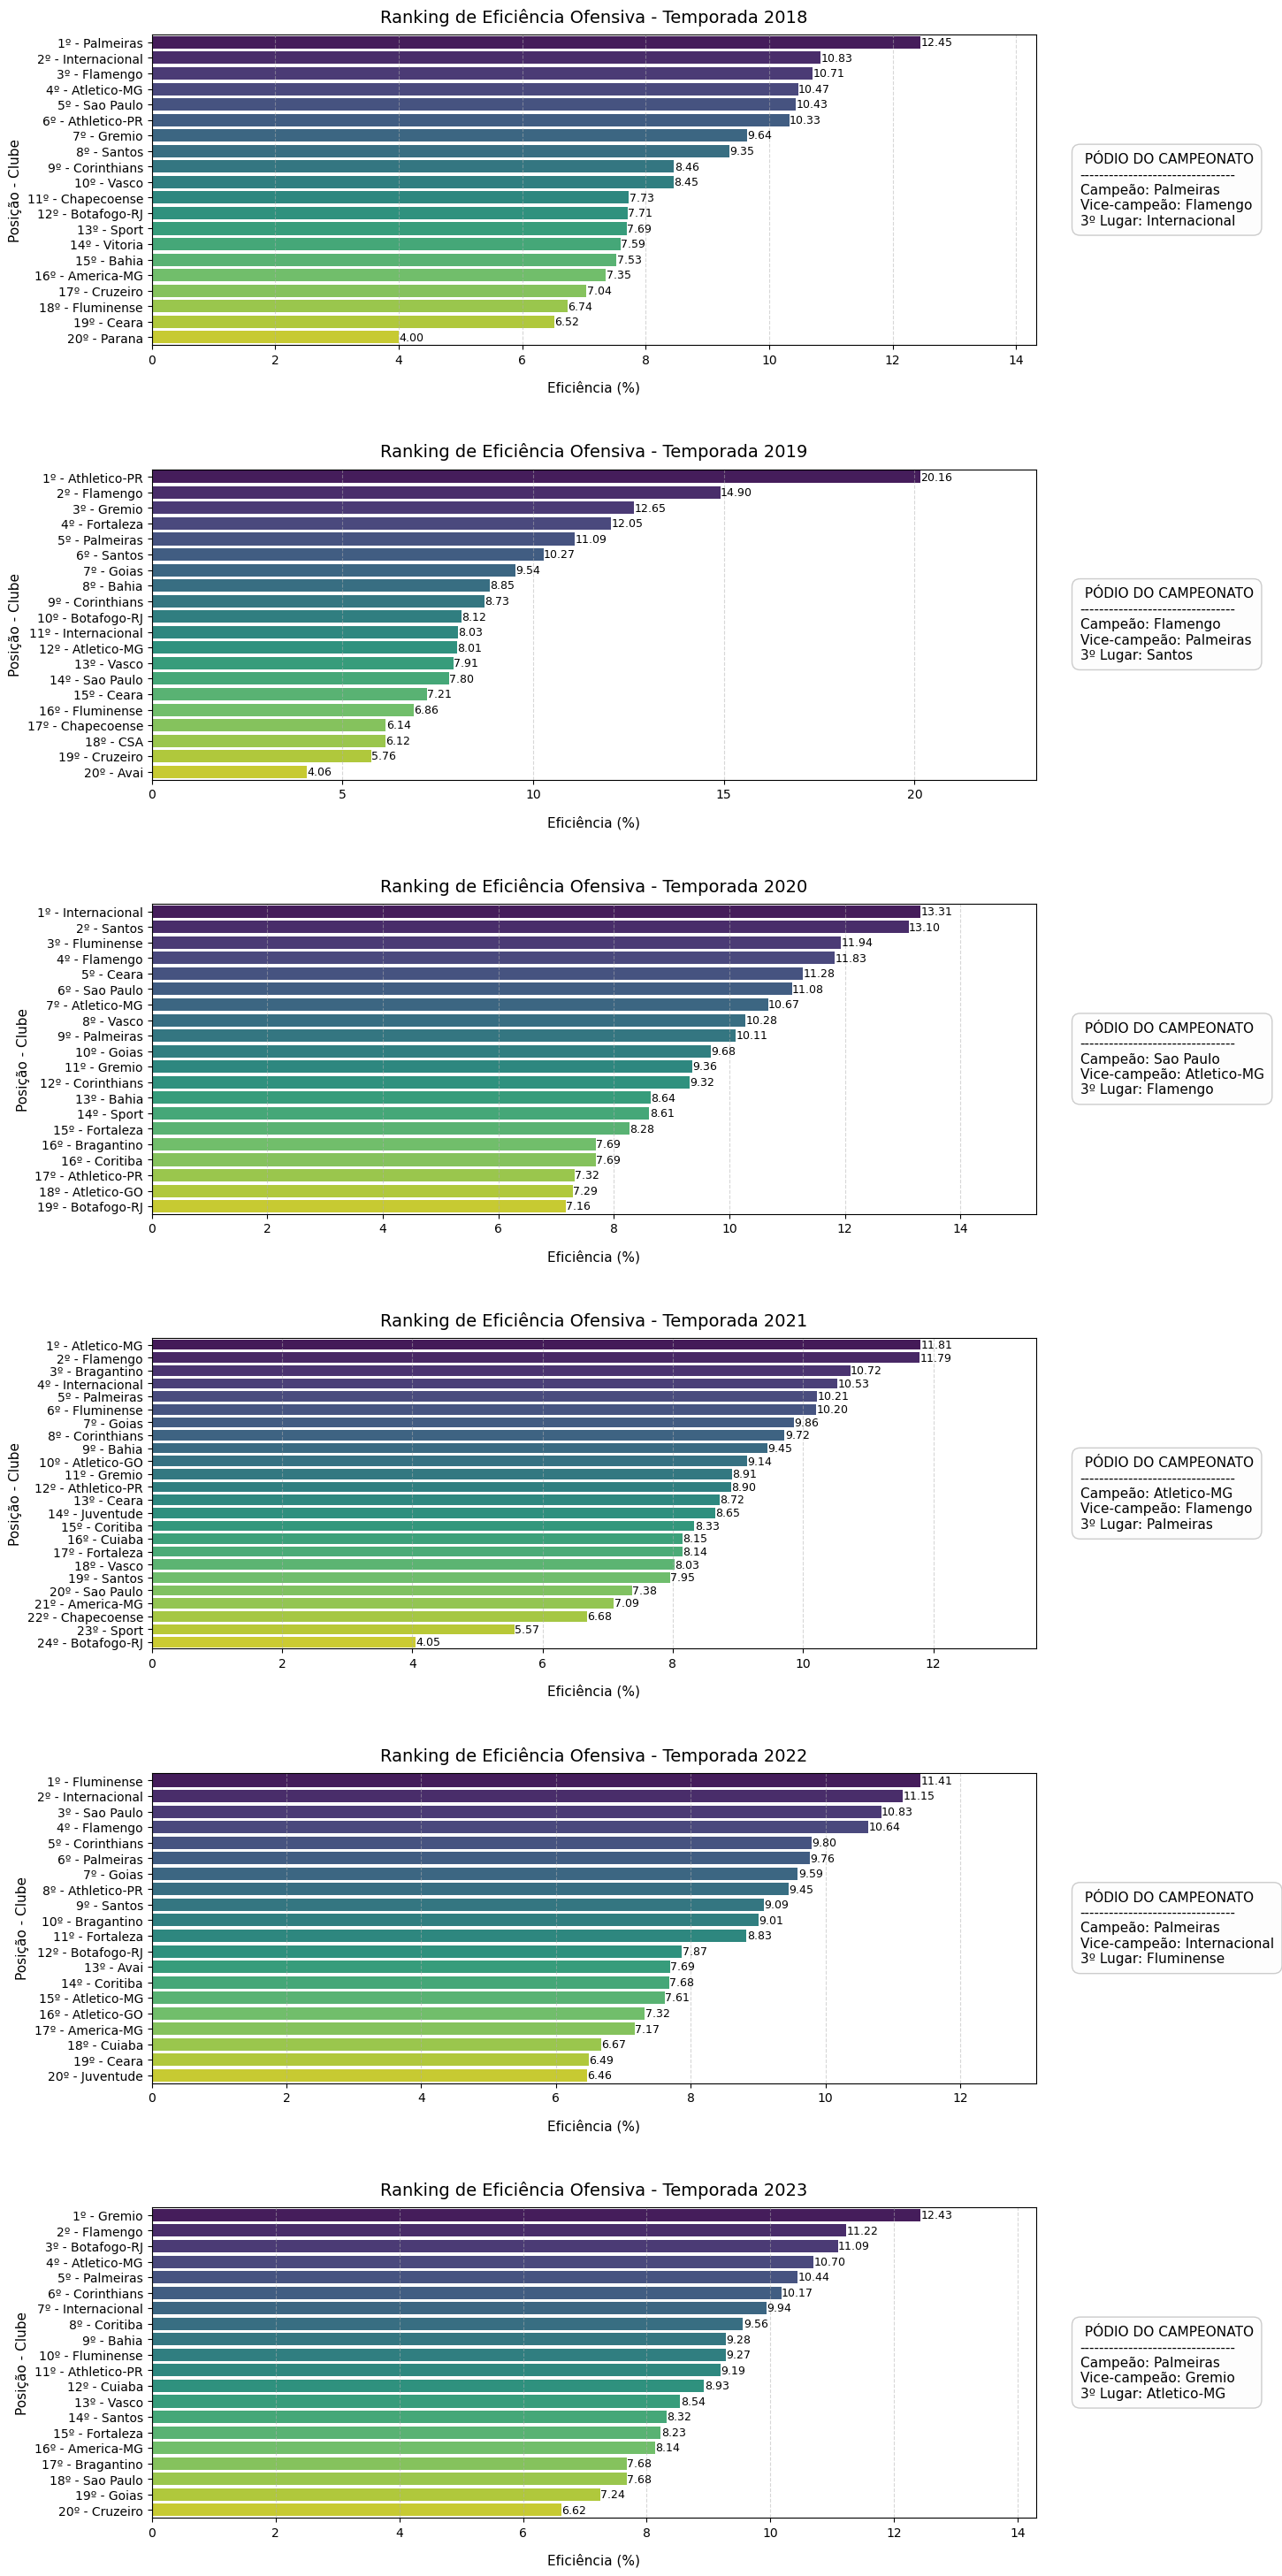

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identificar as temporadas únicas nos dados
temporadas = eficiencia["ano"].unique()
num_temporadas = len(temporadas)

# 2. Configurar a área do gráfico dinamicamente com base no número de anos
fig, axes = plt.subplots(
    nrows=num_temporadas,
    ncols=1,
    figsize=(16, 6 * num_temporadas),
    gridspec_kw={"right": 0.75},
)

# Garantir que 'axes' seja sempre uma lista, mesmo se houver apenas 1 temporada
if num_temporadas == 1:
    axes = [axes]

# 3. Criar um gráfico de barras para cada temporada
for idx, ano in enumerate(temporadas):
    # Filtrar os dados de eficiência apenas do ano atual do loop
    dados_ano = eficiencia[eficiencia["ano"] == ano].copy()  # .copy() evita avisos do pandas

    # Criar a barra horizontal usando o Seaborn
    ax = axes[idx]
    sns.barplot(
        x="eficiencia",
        y="clube",
        data=dados_ano,
        palette="viridis",
        ax=ax,
        hue="clube",
        legend=False,
    )

    ## ------------------ ALTERAÇÃO AQUI: RANKING À ESQUERDA ------------------ ##
    # Criamos uma lista de textos combinando o Ranking + Nome do Clube
    novos_rotulos = [
        f"{row['ranking_ofensivo']}º - {row['clube']}" 
        for _, row in dados_ano.iterrows()
    ]
    # Substituímos os nomes simples do eixo Y por essa nova lista formatada
    ax.set_yticklabels(novos_rotulos)
    ## ----------------------------------------------------------------------- ##

    # Adicionar APENAS o valor da eficiência ao lado de cada barra
    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            if width > 0:
                y_pos = bar.get_y() + bar.get_height() / 2

                # Ajustado para mostrar apenas a porcentagem, já que o ranking foi para a esquerda
                texto = f"{width:.2f}"

                # Coloca o texto imediatamente após o fim da barra
                ax.text(
                    width + 0.005,
                    y_pos,
                    texto,
                    va="center",
                    ha="left",
                    fontsize=9,                )

    # --- SOLUÇÃO DEFINITIVA PARA NÃO CORTAR TEXTO ---
    ax.margins(x=0.15)

    # Garante que os números da régua (ticks) fiquem visíveis neste subgráfico
    ax.tick_params(axis="x", labelbottom=True)

    # --- Buscar o Top 3 do campeonato no DF de pontuação ---
    pontos_ano = pontuacao[pontuacao["ano"] == ano].head(3)

    time_campeao = pontos_ano.iloc[0]["clube"]
    time_vice = pontos_ano.iloc[1]["clube"]
    time_terceiro = pontos_ano.iloc[2]["clube"]

    # Monta a caixinha de texto formatada
    texto_podio = (
        f" PÓDIO DO CAMPEONATO\n"
        f"--------------------------------\n"
        f"Campeão: {time_campeao}\n"
        f"Vice-campeão: {time_vice}\n"
        f"3º Lugar: {time_terceiro}"
    )

    # Adiciona o texto fora do gráfico (à direita)
    ax.text(
        1.05,
        0.5,
        texto_podio,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="center",
        bbox=dict(
            boxstyle="round,pad=0.6",
            facecolor="#fdfdfd",
            edgecolor="#cccccc",
            alpha=1.0,
        ),
    )

    # Customizações estéticas por subgráfico
    ax.set_title(
        f"Ranking de Eficiência Ofensiva - Temporada {ano}", fontsize=14, pad=10
    )
    
    # Mudamos o texto do eixo X, já que o ranking mudou de lugar
    ax.set_xlabel("Eficiência (%)", fontsize=11, labelpad=12)
    ax.xaxis.get_label().set_visible(True)
    
    ax.set_ylabel("Posição - Clube", fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

# Controla o espaçamento manualmente para que o nome do eixo X nunca seja cortado no fundo
plt.subplots_adjust(bottom=0.1, hspace=0.4)
plt.show()




<span style="color: red; font-size: 18px"> OBS.: Aguardar limpeza dos dados para fazer a relação entre eficiencia e melhor colocação, se houver</span>
<br>
<br>
<br>
<br>

In [ ]:
### **2. A formação tática influencia o estilo de jogo e a eficiência ofensiva das equipes? Existe uma formação com mais vitórias**

<font siza='5'>5. Conclusões</font>
<br>
<br>3 a 5 achados defensáveis, escritos para uma **área de negócio**, não para outro programador
<br>Limitações da análise: o que os dados **não** permitem afirmar
<br>Próximos passos: o que vocês investigariam com mais tempo ou mais dados

(Espaço para responder as conclusões)

--------------------------------------------------------------------------------------------------------
<font size='5'>Observações:</font>

Requisitos Git
- [ ] Repositório público, com README preenchido
- [ ] **Todos** os integrantes com commits (o histórico mostra quem fez o quê)
- [ ] No mínimo 15 commits, com mensagens descritivas (`feat: adiciona tratamento de outliers`, não `update`)
- [ ] Uso de pelo menos uma branch além da `main`
- [ ] `.gitignore` adequado (nada de `.ipynb_checkpoints`, `__pycache__` ou credenciais)
- [ ] Notebook commitado **com as saídas executadas**


Para fazer depois que o trabalho estiver pronto:
| 1 min | A base e por que ela foi escolhida |
| 2 min | Estado inicial: o que estava errado nos dados |
| 2 min | Principais decisões de tratamento e suas justificativas |
| 4 min | Os achados, com os gráficos |
| 1 min | Limitações e próximos passos |

Critérios de avaliação por rubrica

| Eixo | Em desenvolvimento | Desenvolvido | Referência |
|---|---|---|---|
| **Git** | Commits concentrados em uma pessoa ou mensagens genéricas | Histórico distribuído, mensagens claras, `.gitignore` correto | Uso fluente de branches; README que permite outra pessoa reproduzir a análise |
| **NumPy** | Uso apenas incidental | Aplica vetorização em pelo menos um cálculo relevante | Escolhe NumPy conscientemente por eficiência e explica o porquê |
| **Pandas** | Operações básicas com erros de alinhamento ou perda silenciosa de linhas | Domina `groupby`, `merge` e `pivot` e confere o resultado | Encadeia operações de forma legível e verifica integridade a cada etapa |
| **Leitura e gravação** | Só lê csv simples | Lida com configurações não triviais e grava em formato adequado | Justifica a escolha do formato de saída (ex.: parquet por tipos e tamanho) |
| **Limpeza e transformação** | Apaga o que incomoda, sem justificar | Trata faltantes, duplicados e outliers justificando cada decisão | Compara estratégias alternativas e mede o impacto de cada uma antes de decidir |
| **Comunicação** | Apresenta código, não conclusões | Achados claros, apoiados em números | Narrativa que uma área de negócio entenderia e usaria para decidir |

## Erros que mais custam nota

1. Concluir coisas que os dados não sustentam (correlação apresentada como causa).
2. Apagar linhas com faltantes sem verificar quantas e quais são — e sem dizer nada sobre isso.
3. Tratar como outlier tudo que é extremo na coluna inteira, sem olhar o grupo de comparação.
4. Fazer `merge` e não conferir se o número de linhas mudou.
5. Gráfico sem título, sem eixo nomeado e sem uma frase dizendo o que ele mostra.
6. Repositório com um único commit no dia da entrega.
